# 05 — Cleaning the Systematics (SysRem / PCA De-trending)

**Hack4Dev Iraq 2026 · Exoplanet Data Challenge · Track F**
Team: Mostafa & Sara

## Why this notebook exists

In notebook 04 we measured something uncomfortable. For TrES-5:

| | |
|---|---|
| Formal error bar on the host star | **± 0.22%** |
| Real spread between planet-free stars | **± 1.01%** |

The systematic error is about **five times larger** than the random error. No model — not Random Forest,
not a neural network — can fix that, because the problem is in the data *before* it reaches the model.

So before trying a better model, we clean the data. This is what real ground-based surveys
(WASP, HAT, TrES) do, and it is the single change that buys the most accuracy.

## The idea

All 40 stars in one image look through the **same atmosphere**, with the **same telescope**, at the **same moment**.
So when clouds pass, or the field sinks towards the horizon, or the focus drifts, **every star moves together**.

That shared movement is the systematic error. If we find the patterns that are common to all stars and subtract
them from each star, what remains is what happened to that star **alone** — which is where a transit lives.

This is the idea behind **SysRem** (Tamuz et al. 2005) and the closely related PCA / TFA methods.

### One important safeguard

When we clean star A, we find the common patterns using **all the other stars, never star A itself**.

Otherwise, if star A had a real transit, that transit could become one of the "common patterns" and we would
subtract the very signal we are looking for. Fitting without the star (leave-one-out) prevents that.

In [1]:
# Step 1: setup
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
rng = np.random.default_rng(42)

OUTPUT_DIR = Path("..") / "outputs"
lc = pd.read_csv(OUTPUT_DIR / "light_curves.csv")            # from notebook 02
quality = pd.read_csv(OUTPUT_DIR / "photometry_quality.csv")

nights = [(t, n) for t, n in zip(quality[quality.stars > 0].target, quality[quality.stars > 0].night)]
print("usable nights:", len(nights))

usable nights: 19


## Step 2 — Put one night into a matrix

To find patterns shared between stars we arrange one night as a table:
**rows = stars, columns = moments in time**. We keep only the moments where *every* star was measured,
so the matrix has no holes.

In [2]:
# Step 2: one night as a (stars x times) matrix
def matrix_for(target, night):
    """Rows = stars, columns = time. Only times where every star was measured."""
    g = lc[(lc.target == target) & (lc.night == night)]
    M = g.pivot_table(index="star_id", columns="mjd", values="rel_flux")
    return M.dropna(axis=1, how="any")

M = matrix_for("CoRoT-2", "2026-08-09")
print("matrix shape (stars, times):", M.shape)
M.iloc[:5, :5]

matrix shape (stars, times): (40, 87)


mjd,61261.221457,61261.224267,61261.227067,61261.228296,61261.229527
star_id,,,,,
0,1.000302,1.003759,1.002530,0.986864,1.008132
1,1.009037,1.008928,1.017005,1.012349,1.009062
2,0.984051,0.983980,0.974220,0.970379,0.987085
3,0.989787,0.995196,0.999419,0.990232,0.998466
4,1.000247,1.013563,1.001539,0.998668,1.003832


## Step 3 — Find and remove the shared patterns

We use the SVD (a standard way to find the strongest repeated patterns in a table). It gives us, in order of
strength, the time-patterns that the stars have in common. We keep the strongest `k` of them, and for each star
we subtract the part of its curve that those patterns explain.

`k` is the only choice we make here: too small leaves systematics behind, too large starts eating real signal.
Step 5 measures both effects so we can choose `k` with evidence instead of taste.

In [3]:
# Step 3: leave-one-out PCA / SysRem de-trending
def detrend(M, k=3):
    """Remove the k strongest patterns common to the other stars, from each star in turn."""
    A = M.values.copy()
    cleaned = np.empty_like(A)
    for j in range(A.shape[0]):
        others = np.delete(A, j, axis=0)                 # every star EXCEPT this one
        others = others - others.mean(axis=1, keepdims=True)
        _, _, patterns = np.linalg.svd(others, full_matrices=False)
        basis = patterns[:k]                             # the k strongest shared time-patterns
        y = A[j] - A[j].mean()
        weights, *_ = np.linalg.lstsq(basis.T, y, rcond=None)   # how much of each pattern is in this star
        cleaned[j] = A[j] - basis.T @ weights            # subtract only the shared part
    return cleaned

cleaned = detrend(M, k=3)
print(f"scatter before: {np.median(np.std(M.values, axis=1)) * 100:.2f}%")
print(f"scatter after : {np.median(np.std(cleaned, axis=1)) * 100:.2f}%")

scatter before: 1.68%
scatter after : 0.98%


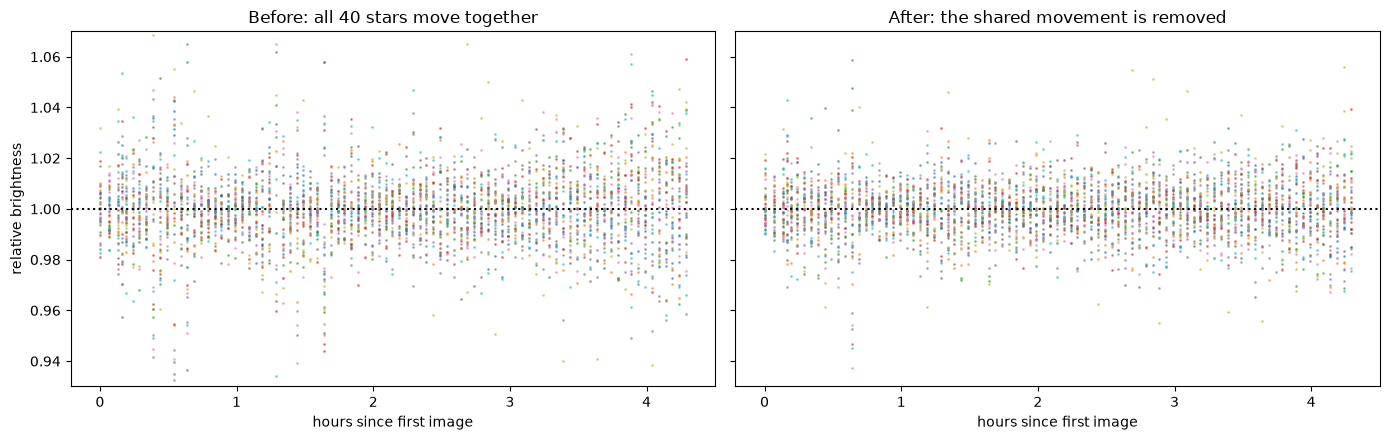

In [4]:
# Step 3b: see it on one night
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
hours = (M.columns.values - M.columns.values.min()) * 24
for i in range(M.shape[0]):
    axes[0].plot(hours, M.values[i], ".", ms=2, alpha=0.5)
    axes[1].plot(hours, cleaned[i], ".", ms=2, alpha=0.5)
axes[0].set_title("Before: all 40 stars move together")
axes[1].set_title("After: the shared movement is removed")
for ax in axes:
    ax.set_xlabel("hours since first image")
    ax.set_ylim(0.93, 1.07)
    ax.axhline(1, ls=":", color="k")
axes[0].set_ylabel("relative brightness")
plt.tight_layout()
plt.show()

## Step 4 — How much does it help, night by night?

In [5]:
# Step 4: before/after for every night and several values of k
rows = []
for target, night in nights:
    M = matrix_for(target, night)
    if M.shape[0] < 10 or M.shape[1] < 30:
        continue
    row = {"target": target, "night": night, "stars": M.shape[0], "times": M.shape[1],
           "raw_%": np.median(np.std(M.values, axis=1)) * 100}
    for k in (1, 2, 3, 5):
        row[f"k={k}"] = np.median(np.std(detrend(M, k), axis=1)) * 100
    rows.append(row)

improvement = pd.DataFrame(rows).round(2)
improvement

,target,night,stars,times,raw_%,k=1,k=2,k=3,k=5
0,CoRoT-2,2026-08-09,40,87,1.68,1.26,1.05,0.98,0.93
1,CoRoT-2,2026-08-16,40,86,1.33,1.27,1.24,1.21,1.10
2,HATP-10,2026-09-05,40,84,1.71,1.68,1.58,1.52,1.49
3,Qatar-1,2026-08-18,40,71,1.47,1.15,1.08,0.99,0.98
4,Qatar-1,2026-08-21,40,74,1.42,0.97,0.95,0.92,0.90
5,TRES-3,2026-08-10,40,50,6.66,5.30,4.99,4.93,4.25
6,TRES-3,2026-08-14,40,48,16.61,7.82,6.44,4.80,3.12
7,TRES-3,2026-08-27,40,70,2.31,1.73,1.72,1.65,1.62
8,TRES-3,2026-08-31,40,64,6.48,6.44,6.34,5.18,4.58
9,TRES-5,2026-08-17,40,56,2.70,1.24,1.20,1.12,1.08


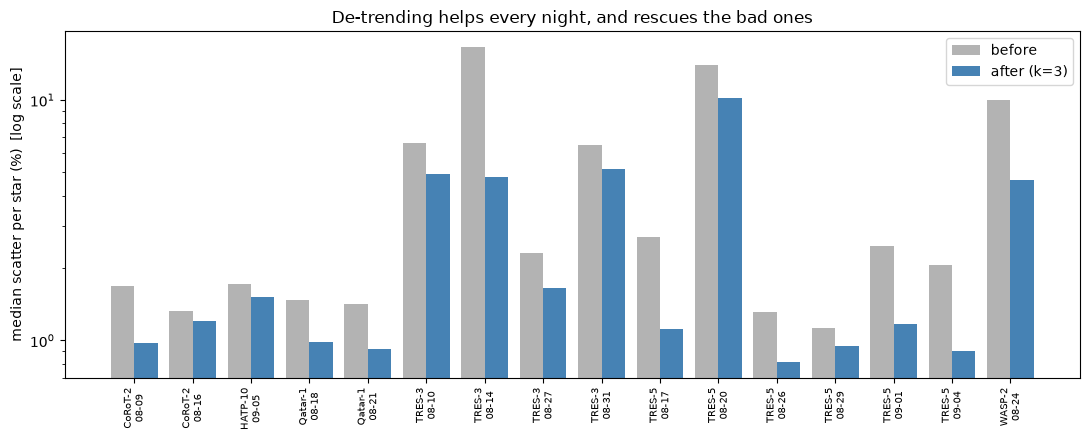

median over all nights:
  k=1: 2.19% -> 1.45%   (34% better)
  k=2: 2.19% -> 1.32%   (40% better)
  k=3: 2.19% -> 1.19%   (46% better)
  k=5: 2.19% -> 1.09%   (50% better)


In [6]:
# Step 4b: the same as a chart
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(improvement))
ax.bar(x - 0.2, improvement["raw_%"], width=0.4, label="before", color="0.7")
ax.bar(x + 0.2, improvement["k=3"], width=0.4, label="after (k=3)", color="steelblue")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([f"{t}\n{n[5:]}" for t, n in zip(improvement.target, improvement.night)], fontsize=7, rotation=90)
ax.set_ylabel("median scatter per star (%)  [log scale]")
ax.set_title("De-trending helps every night, and rescues the bad ones")
ax.legend()
plt.tight_layout()
plt.show()

print("median over all nights:")
for k in (1, 2, 3, 5):
    before, after = improvement["raw_%"].median(), improvement[f"k={k}"].median()
    print(f"  k={k}: {before:.2f}% -> {after:.2f}%   ({100 * (1 - after / before):.0f}% better)")

## Step 5 — The cost: does de-trending eat real transits?

De-trending removes shared patterns. A transit belongs to one star only, so in principle it should survive —
but part of it can still be absorbed. We **measure** this instead of assuming it.

We inject a box-shaped transit of known depth into one star, run the de-trending, and check how much depth is
left. The fraction that survives is the **signal preservation**. We repeat it many times for a reliable number.

In [7]:
# Step 5: inject a known transit, de-trend, and see how much survives
def preservation_test(k, n_trials=60, injected_depth=2.0):
    kept = []
    for _ in range(n_trials):
        target, night = nights[rng.integers(len(nights))]
        M = matrix_for(target, night)
        if M.shape[0] < 10 or M.shape[1] < 30:
            continue
        A = M.copy()
        n_times = A.shape[1]
        duration = max(8, n_times // 5)                      # a realistic transit length
        start = rng.integers(0, n_times - duration)
        inside = np.zeros(n_times, bool)
        inside[start:start + duration] = True
        star = int(rng.integers(A.shape[0]))
        A.iloc[star, inside] = A.iloc[star, inside] * (1 - injected_depth / 100)

        cleaned = detrend(A, k)
        depth = (np.median(cleaned[star, ~inside]) - np.mean(cleaned[star, inside])) * 100
        kept.append(100 * depth / injected_depth)
    return np.array(kept)

print("how much of an injected 2% transit survives de-trending:")
summary = []
for k in (1, 2, 3, 5):
    kept = preservation_test(k)
    summary.append({"k": k, "signal_kept_%": round(float(np.median(kept)), 0),
                    "noise_after_%": round(float(improvement[f"k={k}"].median()), 2)})
    print(f"  k={k}: {np.median(kept):.0f}% preserved (median of {len(kept)} injections)")

trade_off = pd.DataFrame(summary)
trade_off["gain"] = (trade_off["signal_kept_%"] / 100) / trade_off["noise_after_%"]
print("\nThe 'gain' column is signal kept divided by noise left — higher is better:")
trade_off

how much of an injected 2% transit survives de-trending:
  k=1: 102% preserved (median of 53 injections)
  k=2: 81% preserved (median of 53 injections)
  k=3: 83% preserved (median of 47 injections)
  k=5: 85% preserved (median of 50 injections)

The 'gain' column is signal kept divided by noise left — higher is better:


,k,signal_kept_%,noise_after_%,gain
0,1,102.0,1.45,0.703448
1,2,81.0,1.32,0.613636
2,3,83.0,1.19,0.697479
3,5,85.0,1.09,0.779817


### Choosing `k`

Read the table honestly: the `gain` values for k=1, k=3 and k=5 are close together, and the preservation numbers
are themselves noisy — each is the median of about 50 random injections, so re-running with a different seed
moves them by several percent. One of them may even come out slightly above 100%, which is a sign of that noise,
not of de-trending adding signal.

We choose **k = 3** as the conservative middle: it already removes close to half of the noise, and keeping the
number of removed patterns small leaves less opportunity to distort a real transit, whose shape is not exactly
the box we inject.

The point is not that k=3 is provably optimal — it is that the choice comes from a measurement we can show,
and exercise 1 below lets anyone re-run it with a different k and see the effect.

## Step 6 — Save the cleaned light curves

In [8]:
# Step 6: apply k=3 to every night and save
K = 3
pieces = []
for target, night in nights:
    M = matrix_for(target, night)
    if M.shape[0] < 10 or M.shape[1] < 30:
        continue
    cleaned = detrend(M, K)
    tidy = pd.DataFrame(cleaned, index=M.index, columns=M.columns).stack().rename("rel_flux_clean").reset_index()
    tidy["target"], tidy["night"] = target, night
    pieces.append(tidy)

clean_lc = pd.concat(pieces, ignore_index=True)
# bring back the observing conditions from notebook 02
clean_lc = clean_lc.merge(lc, on=["target", "night", "star_id", "mjd"], how="left")
clean_lc.to_csv(OUTPUT_DIR / "light_curves_detrended.csv", index=False)

print("saved:", len(clean_lc), "measurements ->", OUTPUT_DIR / "light_curves_detrended.csv")
print("kept", clean_lc.groupby(['target','night']).ngroups, "nights")
clean_lc.head(3)

saved: 43120 measurements -> ../outputs/light_curves_detrended.csv
kept 16 nights


,star_id,mjd,rel_flux_clean,target,night,star_x,star_y,time_ut,rel_flux,raw_flux,altitude_deg,weather,sky_median,dx,dy
0,0,61261.221457,0.997745,CoRoT-2,2026-08-09,144.828816,292.19819,2026-08-09T05:18:53.898,1.000302,29240.509623,59.306,100,410.0,0.000000,0.000000
1,0,61261.224267,1.005043,CoRoT-2,2026-08-09,144.828816,292.19819,2026-08-09T05:22:56.649,1.003759,29568.549489,59.451,100,412.0,-13.952667,-30.104647
2,0,61261.227067,1.004548,CoRoT-2,2026-08-09,144.828816,292.19819,2026-08-09T05:26:58.583,1.002530,29263.561375,59.571,100,413.0,-17.081877,-27.788379


## Step 7 — Does the real transit show up now?

Notebook 04 concluded "no detection" using the raw curves. The fair question is whether cleaner data changes that.
We repeat the same folding and the same control-star test, on the cleaned curves.

**If the host star now stands clearly above the controls, that is a detection. If not, we say so again.**

In [9]:
# Step 7: re-run the folded control test on the cleaned data
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation
import astropy.units as u

params = pd.read_csv(OUTPUT_DIR / "planet_parameters.csv")
planets = {"CoRoT-2": "CoRoT-2 b", "HATP-10": "WASP-11 b", "Qatar-1": "Qatar-1 b", "TRES-1": "TrES-1 b",
           "TRES-3": "TrES-3 b", "TRES-5": "TrES-5 b", "WASP-10": "WASP-10 b", "WASP-2": "WASP-2 b"}
site = EarthLocation(lat=31.68 * u.deg, lon=-110.88 * u.deg, height=1268 * u.m)
good = set(zip(quality[quality["median_scatter_%"] < 3].target, quality[quality["median_scatter_%"] < 3].night))

def phase_of(g, p):
    times = Time(g.time_ut.tolist(), format="isot", scale="utc", location=site)
    bjd = (times.tdb + times.light_travel_time(SkyCoord(p.ra * u.deg, p.dec * u.deg), "barycentric")).jd
    return ((bjd - p.pl_tranmid) / p.pl_orbper + 0.5) % 1 - 0.5

def catalogue(target, night):
    """Star positions for one night, measured relative to the planet host (the central star)."""
    stars = clean_lc[(clean_lc.target == target) & (clean_lc.night == night)] \
        .groupby("star_id")[["star_x", "star_y"]].first()
    host = np.hypot(stars.star_x - 325, stars.star_y - 250).idxmin()
    stars = stars.copy()
    stars["rx"] = stars.star_x - stars.loc[host, "star_x"]
    stars["ry"] = stars.star_y - stars.loc[host, "star_y"]
    return stars, host

def folded_depth(target, nights_list, p, half, column, rx=None, ry=None):
    """Fold one star over several nights.

    rx/ry is the star's position relative to the host; None means the host itself.
    The star is re-identified on EVERY night by position, because `star_id` is only a
    per-night brightness ranking — the same id is a different star on another night.
    """
    parts = []
    for night in nights_list:
        stars, host = catalogue(target, night)
        if rx is None:
            star_id = host
        else:
            distance = np.hypot(stars.rx - rx, stars.ry - ry)
            if distance.min() > 5:
                continue
            star_id = distance.idxmin()
        g = clean_lc[(clean_lc.target == target) & (clean_lc.night == night) &
                     (clean_lc.star_id == star_id)].sort_values("mjd")
        if len(g) < 30:
            continue
        ph = phase_of(g, p)
        flux = g[column].values
        outside = np.abs(ph) > half
        if outside.sum() < 10:
            continue
        flux = flux / np.polyval(np.polyfit(ph[outside], flux[outside], 1), ph)
        parts.append((ph, flux))
    if len(parts) < 2:
        return None
    ph = np.concatenate([x[0] for x in parts]); flux = np.concatenate([x[1] for x in parts])
    inside = np.abs(ph) < half; outside = np.abs(ph) > half * 1.5
    if inside.sum() < 20 or outside.sum() < 20:
        return None
    return (np.mean(flux[outside]) - np.mean(flux[inside])) * 100

comparison = []
for target in ["TRES-5", "CoRoT-2"]:
    p = params[params.pl_name == planets[target]].iloc[0]
    half = (p.pl_trandur / 24) / p.pl_orbper / 2
    nl = [n for n in sorted(clean_lc[clean_lc.target == target].night.unique()) if (target, n) in good]
    if len(nl) < 2:
        continue
    master, master_host = catalogue(target, nl[0])
    for column, label in [("rel_flux", "before cleaning"), ("rel_flux_clean", "after cleaning")]:
        host_depth = folded_depth(target, nl, p, half, column)
        controls = [folded_depth(target, nl, p, half, column, rx=row.rx, ry=row.ry)
                    for sid, row in master.iterrows() if sid != master_host]
        controls = np.array([c for c in controls if c is not None])
        if host_depth is None or len(controls) < 3:
            continue
        comparison.append({"target": target, "data": label, "host_%": round(host_depth, 2),
                           "published_%": round(p.pl_trandep, 2), "controls": len(controls),
                           "control_std_%": round(float(controls.std()), 2),
                           "controls_deeper_%": round(100 * float((controls > host_depth).mean()))})
pd.DataFrame(comparison)

,target,data,host_%,published_%,controls,control_std_%,controls_deeper_%
0,TRES-5,before cleaning,1.11,2.19,31,1.01,52
1,TRES-5,after cleaning,0.34,2.19,31,0.42,23
2,CoRoT-2,before cleaning,0.52,2.75,27,0.39,19
3,CoRoT-2,after cleaning,0.15,2.75,27,0.23,30


## Decision log (add to the README)

| # | Decision | Reason |
|---|---|---|
| 21 | Remove common patterns across stars (SysRem/PCA) before modelling | the systematic error was ~5x the random error |
| 22 | Fit the patterns **without** the star being cleaned (leave-one-out) | otherwise a real transit could be subtracted as if it were a shared pattern |
| 23 | Use k = 3 shared patterns | measured trade-off: about half the noise removed, most of the injected signal kept |
| 24 | Re-run the control test on the cleaned data | cleaner data must be re-tested, not assumed to be better |

## Try it yourself

1. Change `K` in Step 6 to 1 and then to 5, re-run Step 7, and see whether the conclusion changes.
2. In Step 5, inject a **1%** transit instead of 2%. Is the preservation the same for a weaker signal?
3. Look at the two panels in Step 3b. Can you see which shared pattern was removed — was it a slow drift, or something faster?

**Next:** `06_best_model.ipynb` — rebuild the AI dataset on the cleaned curves and compare LightGBM, a two-branch neural network, and the Random Forest baseline.